# Multinomial Logistic Regression 

**Module:** IT3051 - Fundamentals of Data Mining  
**Project:** Next-Year PM2.5 Air-Quality Risk Classification  
**Responsibility:** Multinomial Logistic Regression Baseline

## Objectives
1. Load the existing chronological train/validation/test splits.
2. Check the target distribution.
3. Remove identifier columns and prevent target leakage.
4. Build preprocessing using training data only.
5. Train Multinomial Logistic Regression.
6. Evaluate on the validation set.
7. Produce Accuracy, Balanced Accuracy, Macro-F1, Weighted-F1 and Quadratic Weighted Kappa.
8. Produce a classification report and confusion matrices.
9. Check prediction confidence.
10. Save the model, metrics and results for the group.

The notebook follows the leakage-safety requirements: preprocessing is fitted on training data only, validation/test data are transformed only, and identifiers/target are excluded from predictors.

In [8]:
# IMPORT LIBRARIES

from pathlib import Path
import json
import sys
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42



# Make this work when the notebook is run from the project's notebooks folder
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.preprocessing_pipeline import (
    TARGET_COLUMN,
    prepare_base_dataframe,
    prepare_features_and_target,
    build_preprocessor,
)

print("Imports loaded successfully.")
print("Project root:", project_root)



Imports loaded successfully.
Project root: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project


In [9]:
processed_dir = project_root / "data" / "processed"

train_path = processed_dir / "train_data.csv"
validation_path = processed_dir / "validation_data.csv"
test_path = processed_dir / "test_data.csv"

required_files = [train_path, validation_path, test_path]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run 07_make_dataset.ipynb first to create the chronological split files."
        )

identifier_types = {
    "site_id": "string",
    "state_code": "string",
    "county_code": "string",
    "site_num": "string",
}

train_df = pd.read_csv(train_path, dtype=identifier_types, low_memory=False)
validation_df = pd.read_csv(validation_path, dtype=identifier_types, low_memory=False)
test_df = pd.read_csv(test_path, dtype=identifier_types, low_memory=False)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)


Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 2. Confirm the Chronological Split

This check helps confirm that future years are not mixed into the training data.


In [10]:
for name, dataset in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    print(
        f"{name}: {dataset['year'].min()} - {dataset['year'].max()} "
        f"({len(dataset)} rows)"
    )


Training: 1997 - 2012 (13191 rows)
Validation: 2013 - 2014 (1783 rows)
Test: 2015 - 2016 (1561 rows)


## 3. Apply Base Cleaning to Each Split

We use the same base-cleaning function used in the preprocessing notebook.  
Each split is handled separately.


In [11]:
train_prepared = prepare_base_dataframe(train_df)
validation_prepared = prepare_base_dataframe(validation_df)
test_prepared = prepare_base_dataframe(test_df)

print("Base preprocessing completed.")
print("Training shape:", train_prepared.shape)
print("Validation shape:", validation_prepared.shape)
print("Test shape:", test_prepared.shape)


Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Base preprocessing completed.
Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 4. Separate Features and Target

The target is `pm25_risk_category_next_year`.

Identifier columns are excluded by the existing project preprocessing function.


In [12]:
X_train, y_train = prepare_features_and_target(train_prepared)
X_val, y_val = prepare_features_and_target(validation_prepared)
X_test, y_test = prepare_features_and_target(test_prepared)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())


Feature matrix shape: (13191, 33)
Target shape: (13191,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1783, 33)
Target shape: (1783,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1561, 33)
Target shape: (1561,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
X_train: (13191, 33) | y_train: (13191,)
X_val: (1783, 33) | y_val: (1783,)
X_test: (1561, 33) | y_test: (1561,)

Training target distribution:
pm25_risk_category_next_year
Moderate                          6849
Unhealthy for Sensitive Groups    5049
Unhealthy                         1203
Good                                52
Very Unhealthy                      38
Name: count, dtype: int64


## 5. Build and Fit the Preprocessor

Important: the preprocessor is **fitted only on `X_train`**.

The fitted training preprocessor is then used to transform validation and test features.  
This prevents information leakage from future data.


In [13]:
preprocessor = build_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Prepare test features with the same fitted transformer,
# but do not use y_test for baseline model selection.
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Numerical features: 29
Categorical features: 4
Preprocessing completed.
Processed training shape: (13191, 2154)
Processed validation shape: (1783, 2154)
Processed test shape: (1561, 2154)


In [14]:
# CHECK TARGET DISTRIBUTION ACROSS ALL SPLITS

all_classes = sorted(
    set(y_train.unique()) |
    set(y_val.unique()) |
    set(y_test.unique())
)

distribution_table = pd.DataFrame(index=all_classes)

for split_name, y_split in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test),
]:
    distribution_table[f"{split_name}_count"] = (
        y_split.value_counts().reindex(all_classes, fill_value=0)
    )

display(distribution_table)

print("Number of target classes:", len(all_classes))
print("Classes:")
for i, class_name in enumerate(all_classes, start=1):
    print(i, "-", class_name)

,Train_count,Validation_count,Test_count
Good,52,5,29
Moderate,6849,1282,1287
Unhealthy,1203,127,68
Unhealthy for Sensitive Groups,5049,356,173
Very Unhealthy,38,13,4


Number of target classes: 5
Classes:
1 - Good
2 - Moderate
3 - Unhealthy
4 - Unhealthy for Sensitive Groups
5 - Very Unhealthy


## 6. Leakage and Identifier Checks

The target is `pm25_risk_category_next_year`.

Identifier columns are removed from the predictors. Future-year target information must not be used as an input feature.

In [15]:
# REMOVE IDENTIFIERS / CHECK FOR TARGET LEAKAGE

identifier_columns = [
    "site_id",
    "state_code",
    "county_code",
    "site_num",
]

present_identifier_columns = [
    column for column in identifier_columns
    if column in X_train.columns
]

print("Identifier columns found in X_train:")
print(present_identifier_columns)

print("\nTarget present in X_train:", TARGET_COLUMN in X_train.columns)

X_train = X_train.drop(
    columns=present_identifier_columns,
    errors="ignore"
)
X_val = X_val.drop(
    columns=present_identifier_columns,
    errors="ignore"
)
X_test = X_test.drop(
    columns=present_identifier_columns,
    errors="ignore"
)

assert TARGET_COLUMN not in X_train.columns
assert TARGET_COLUMN not in X_val.columns
assert TARGET_COLUMN not in X_test.columns

print("\nLeakage check passed.")
print("X_train shape after identifier removal:", X_train.shape)

Identifier columns found in X_train:
[]

Target present in X_train: False

Leakage check passed.
X_train shape after identifier removal: (13191, 33)


## 7. Identify Numerical and Categorical Features

Numerical features will use median imputation and StandardScaler.

Categorical features will use most-frequent imputation and OneHotEncoder.

In [16]:
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['year', 'latitude', 'longitude', 'observation_count', 'observation_percent', 'valid_day_count', 'arithmetic_standard_dev', 'first_max_value', 'ninety_nine_percentile', 'ninety_eight_percentile', 'ninety_five_percentile', 'ninety_percentile', 'seventy_five_percentile', 'fifty_percentile', 'ten_percentile', 'pm25_mean', 'pm25_lag1', 'pm25_change_1yr', 'pm25_pct_change_1yr', 'pm25_lag2', 'pm25_rolling_2yr_mean', 'pm25_rolling_3yr_mean', 'pm25_rolling_3yr_std', 'p95_minus_median', 'p99_p10_range', 'max_to_mean_ratio', 'observations_per_valid_day', 'has_previous_year', 'has_three_year_history']

Categorical features:
['state_name', 'county_name', 'city_name', 'cbsa_name']

Number of numerical features: 29
Number of categorical features: 4


In [17]:
# CREATE PREPROCESSING PIPELINE

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

print("Preprocessing pipeline created.")
print("Numerical: median imputation + StandardScaler")
print("Categorical: most-frequent imputation + OneHotEncoder")

Preprocessing pipeline created.
Numerical: median imputation + StandardScaler
Categorical: most-frequent imputation + OneHotEncoder


## 8. Create Multinomial Logistic Regression

`class_weight="balanced"` helps prevent the majority class from dominating the model.

`C=1.0` is used for the baseline. Hyperparameter tuning can be performed later in Stage 7.

In [18]:
# CREATE COMPLETE LOGISTIC REGRESSION PIPELINE

logistic_model = LogisticRegression(
    solver="lbfgs",
    penalty="l2",
    C=1.0,
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", logistic_model),
])

print("Multinomial Logistic Regression pipeline created.")
print(logistic_model)

Multinomial Logistic Regression pipeline created.
LogisticRegression(class_weight='balanced', max_iter=2000, penalty='l2',
                   random_state=42)


In [19]:
# TRAIN MODEL

start_time = time.time()

logistic_pipeline.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds.")
print("\nLearned classes:")
print(logistic_pipeline.named_steps["classifier"].classes_)

Training completed in 26.34 seconds.

Learned classes:
['Good' 'Moderate' 'Unhealthy' 'Unhealthy for Sensitive Groups'
 'Very Unhealthy']


In [20]:
# 11. VALIDATION PREDICTIONS

y_val_pred = logistic_pipeline.predict(X_val)
y_val_proba = logistic_pipeline.predict_proba(X_val)

print("First 20 actual values:")
print(y_val.iloc[:20].tolist())

print("\nFirst 20 predicted values:")
print(y_val_pred[:20].tolist())

print("\nProbability matrix shape:", y_val_proba.shape)

First 20 actual values:
['Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Unhealthy']

First 20 predicted values:
['Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Good', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate']

Probability matrix shape: (1783, 5)


## 9. Validation Metrics

The notebook reports Accuracy, Balanced Accuracy, Macro Precision, Macro Recall, Macro-F1, Weighted-F1 and Quadratic Weighted Kappa.

Macro-F1 is especially useful when the risk classes are imbalanced. QWK is also reported because the risk categories have an ordered interpretation.

In [21]:
# CALCULATE VALIDATION METRICS

accuracy = accuracy_score(y_val, y_val_pred)

balanced_accuracy = balanced_accuracy_score(
    y_val, y_val_pred
)

macro_precision = precision_score(
    y_val, y_val_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_val, y_val_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val, y_val_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_val, y_val_pred,
    average="weighted",
    zero_division=0
)

risk_order = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous",
]

qwk_labels = [
    label for label in risk_order
    if label in set(y_val.unique()) or label in set(y_val_pred)
]

qwk = cohen_kappa_score(
    y_val,
    y_val_pred,
    labels=qwk_labels,
    weights="quadratic"
)

validation_metrics = {
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "quadratic_weighted_kappa": qwk,
    "training_time_seconds": training_time,
}

metrics_table = pd.DataFrame(
    validation_metrics.items(),
    columns=["Metric", "Value"]
)

metrics_table["Value"] = metrics_table["Value"].round(4)

display(metrics_table)

,Metric,Value
0,accuracy,0.7291
1,balanced_accuracy,0.4381
2,macro_precision,0.4059
3,macro_recall,0.4381
4,macro_f1,0.3501
5,weighted_f1,0.6916
6,quadratic_weighted_kappa,0.4319
7,training_time_seconds,26.3385


In [22]:
# CLASSIFICATION REPORT

labels_present = [
    label for label in risk_order
    if label in set(y_val.unique()) or label in set(y_val_pred)
]

classification_report_text = classification_report(
    y_val,
    y_val_pred,
    labels=labels_present,
    zero_division=0,
)

print(classification_report_text)



                                precision    recall  f1-score   support

                          Good       0.05      0.40      0.09         5
                      Moderate       0.79      0.93      0.85      1282
Unhealthy for Sensitive Groups       0.62      0.13      0.22       356
                     Unhealthy       0.47      0.42      0.44       127
                Very Unhealthy       0.10      0.31      0.15        13

                      accuracy                           0.73      1783
                     macro avg       0.41      0.44      0.35      1783
                  weighted avg       0.73      0.73      0.69      1783



## 10. Confusion Matrix — Raw Counts

Rows represent actual classes and columns represent predicted classes.

,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy
Good,2,3,0,0,0
Moderate,33,1193,22,19,15
Unhealthy for Sensitive Groups,3,256,48,36,13
Unhealthy,4,53,7,53,10
Very Unhealthy,0,5,0,4,4


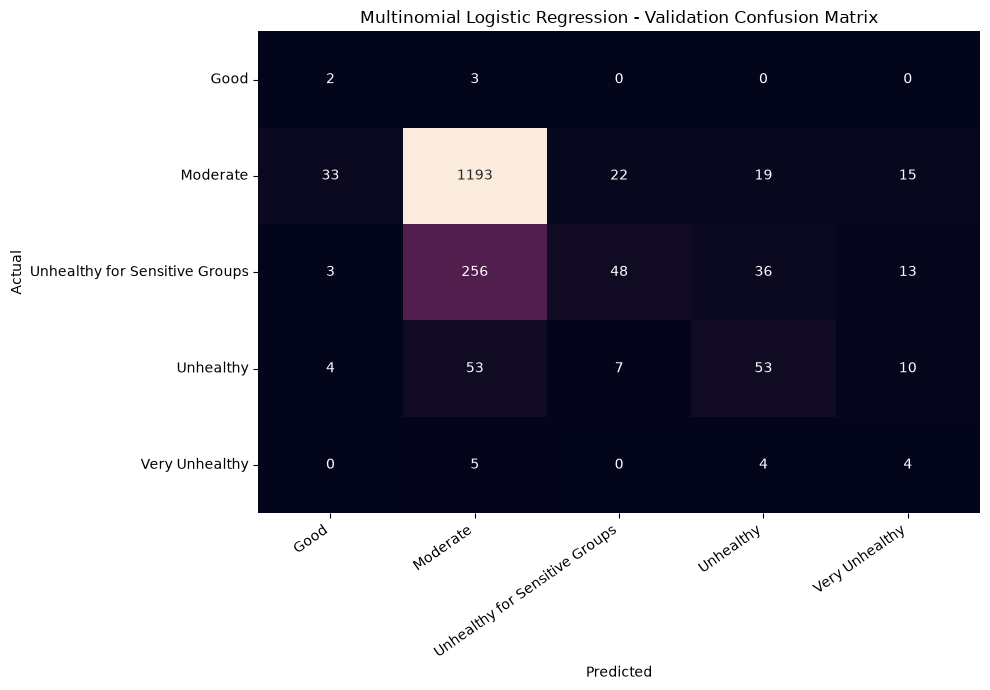

In [24]:
# CONFUSION MATRIX - RAW COUNTS

cm = confusion_matrix(
    y_val,
    y_val_pred,
    labels=labels_present
)

cm_df = pd.DataFrame(
    cm,
    index=labels_present,
    columns=labels_present
)

display(cm_df)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cbar=False
)

plt.title(
    "Multinomial Logistic Regression - Validation Confusion Matrix"
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Confusion Matrix — Row Normalized

The normalized matrix helps show the recall pattern for each actual risk class.

,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy
Good,0.400,0.600,0.000,0.000,0.000
Moderate,0.026,0.931,0.017,0.015,0.012
Unhealthy for Sensitive Groups,0.008,0.719,0.135,0.101,0.037
Unhealthy,0.031,0.417,0.055,0.417,0.079
Very Unhealthy,0.000,0.385,0.000,0.308,0.308


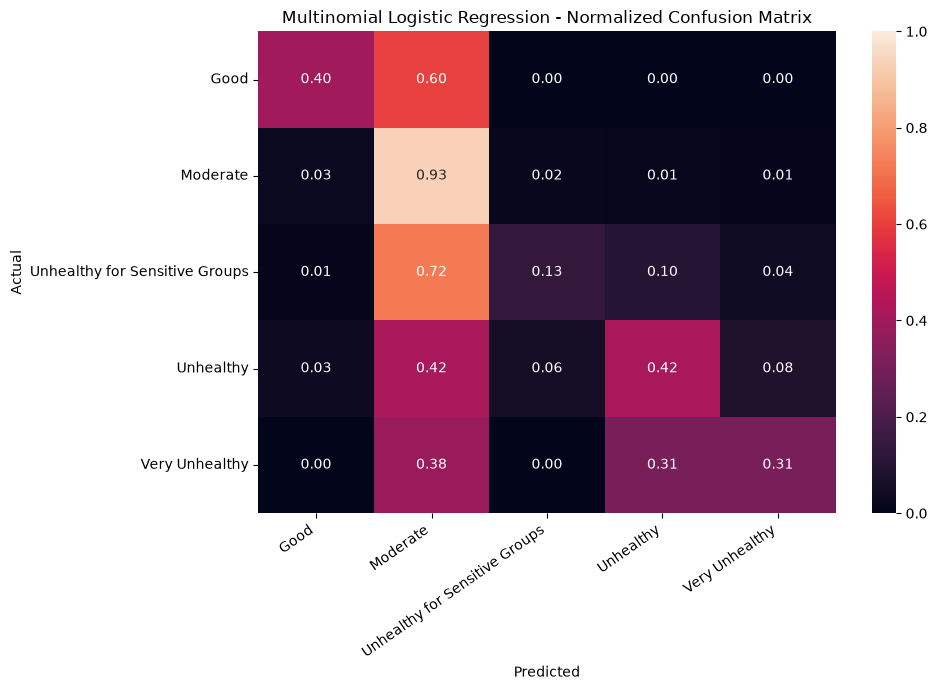

In [26]:
# CONFUSION MATRIX - NORMALIZED

row_totals = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm.astype(float),
    row_totals,
    out=np.zeros_like(cm, dtype=float),
    where=row_totals != 0
)

cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=labels_present,
    columns=labels_present
)

display(cm_normalized_df.round(3))

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_normalized_df,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1
)

plt.title(
    "Multinomial Logistic Regression - Normalized Confusion Matrix"
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()



## 9. Prediction Confidence

The highest predicted class probability is used as a simple confidence measure.

It represents the model's estimated probability for its selected class; it does not guarantee that the prediction is correct.

In [27]:
# 16. PREDICTION CONFIDENCE

prediction_confidence = y_val_proba.max(axis=1)

print("Average prediction confidence:",
      round(prediction_confidence.mean(), 4))

print("Minimum prediction confidence:",
      round(prediction_confidence.min(), 4))

print("Maximum prediction confidence:",
      round(prediction_confidence.max(), 4))

display(
    pd.Series(prediction_confidence)
    .describe()
    .to_frame("confidence")
)

Average prediction confidence: 0.8117
Minimum prediction confidence: 0.2925
Maximum prediction confidence: 0.9955


,confidence
count,1783.000000
mean,0.811742
std,0.159244
min,0.292471
25%,0.721598
50%,0.870294
75%,0.937141
max,0.995487


In [ ]:
# 17. HIGH-RISK CLASS PERFORMANCE

high_risk_classes = [
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous",
]

class_report_df = pd.DataFrame(
    classification_report(
        y_val,
        y_val_pred,
        labels=labels_present,
        output_dict=True,
        zero_division=0,
    )
).T

high_risk_present = [
    c for c in high_risk_classes
    if c in class_report_df.index
]

print("High-risk class performance:")

if high_risk_present:
    display(
        class_report_df.loc[
            high_risk_present,
            ["precision", "recall", "f1-score", "support"]
        ].round(4)
    )
else:
    print("No high-risk classes were present in this validation split.")

## 11. Optional Final Test Evaluation

Do not repeatedly use the test set while developing the model.

Set `run_final_test = True` only when the group has completed model comparison and is ready for the final held-out evaluation.

In [ ]:
# 20. FINAL TEST EVALUATION

run_final_test = False

if run_final_test:

    y_test_pred = logistic_pipeline.predict(X_test)

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_macro_recall = recall_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0
    )

    test_macro_f1 = f1_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0
    )

    print("FINAL TEST RESULTS")
    print("------------------")
    print(f"Accuracy     : {test_accuracy:.4f}")
    print(f"Macro Recall : {test_macro_recall:.4f}")
    print(f"Macro F1     : {test_macro_f1:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_test_pred,
            zero_division=0
        )
    )

else:
    print(
        "Test evaluation is disabled. "
        "Set run_final_test = True only for final evaluation."
    )

: 